In [56]:
# ======================================================
# 1: Install extra libraries and import packages
# ======================================================
!pip install -q imbalanced-learn joblib xgboost

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix
)

# Traditional ML models
from sklearn.linear_model import LogisticRegression           # GLM (Logit)
from sklearn.naive_bayes import GaussianNB                    # NB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis  # FLM (LDA)
from sklearn.tree import DecisionTreeClassifier               # DT
from sklearn.ensemble import RandomForestClassifier           # RF
from sklearn.svm import SVC                                   # SVM (RBF)

# Gradient boosting
from xgboost import XGBClassifier                             # GBT (XGBoost)

# Deep Learning
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

import joblib

RANDOM_STATE = 42
sns.set(style="whitegrid")



In [57]:
# ======================================================
# 2: Load the cleaned insider threat dataset
# ======================================================
df = pd.read_csv("/content/drive/MyDrive/AppliedResearchProj_Dataset/Coding_Dataset/AppliedResearchDataset_cleanVer1.csv")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nTarget distribution (is_insider):")
print(df["is_insider"].value_counts())
print("\nTarget distribution (normalised):")
print(df["is_insider"].value_counts(normalize=True))


Shape: (12000, 15)

First 5 rows:


,is_insider,id,user,pc,event_src,activity,date,to_removable_media,from_removable_media,size,Openness score,Conscientiousness score,Extraversion score,Agreeableness score,Neuroticism score
0,True,{T2N6-X9QL06RX-0762MGAR},CSC0217,PC-5391,logon,Logon,6/10/2010 0:00,False,False,0,40,15,30,38,28
1,True,{H5W6-B8OS58UZ-7808LFON},CSC0217,PC-6377,logon,Logon,6/11/2010 0:00,False,False,0,40,15,30,38,28
2,True,{J4H8-U4HY76KF-8654QSST},CSC0217,PC-6377,logon,Logon,6/11/2010 0:00,False,False,0,40,15,30,38,28
3,True,{K7J1-R9NA31CC-0202USEF},CSC0217,PC-5391,logon,Logoff,6/10/2010 0:00,False,False,0,40,15,30,38,28
4,True,{E6S3-A8MW97SQ-7179CYTE},CSC0217,PC-9873,logon,Logoff,6/10/2010 0:00,False,False,0,40,15,30,38,28



Target distribution (is_insider):
is_insider
True     6000
False    6000
Name: count, dtype: int64

Target distribution (normalised):
is_insider
True     0.5
False    0.5
Name: proportion, dtype: float64


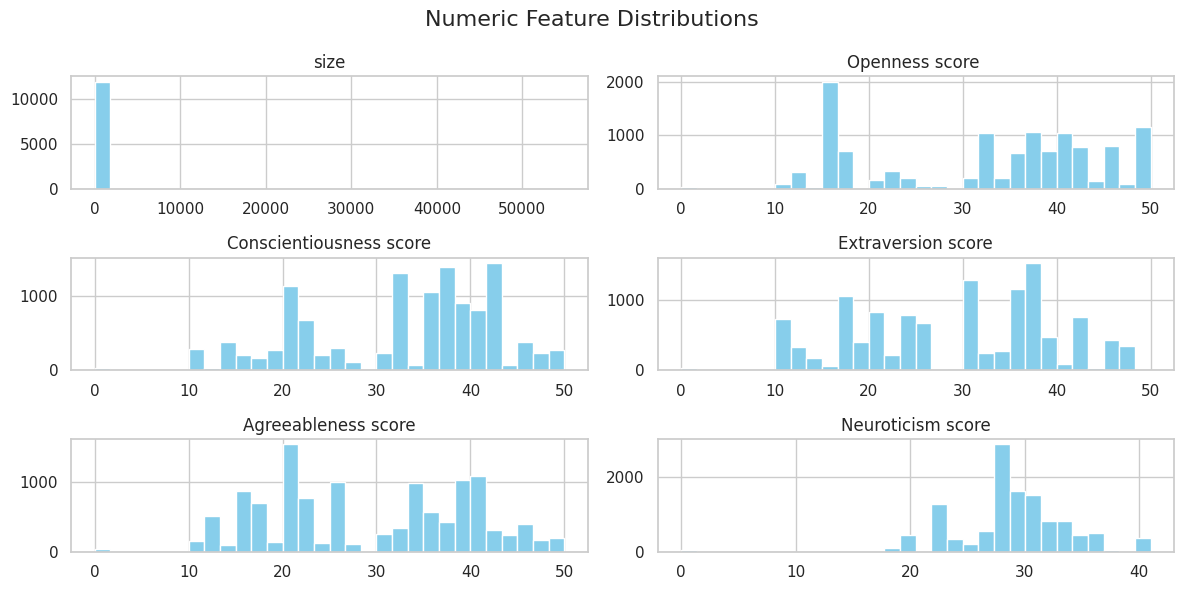

In [58]:
# ======================
# EDA: Histograms
# ======================

numeric_cols = [
    "size",
    "Openness score ",
    "Conscientiousness score",
    "Extraversion score",
    "Agreeableness score",
    "Neuroticism score"
]

df[numeric_cols].hist(figsize=(12, 6), bins=30, color="skyblue")
plt.suptitle("Numeric Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()


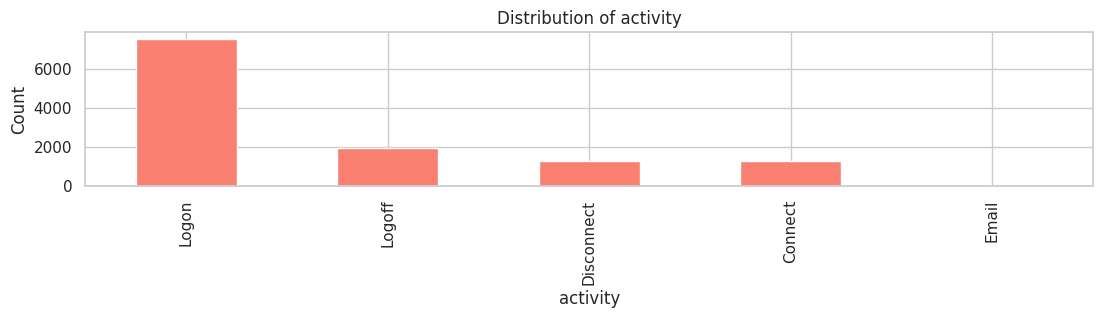

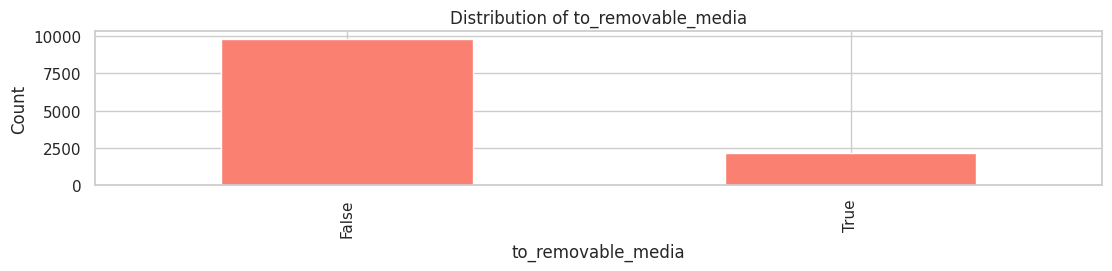

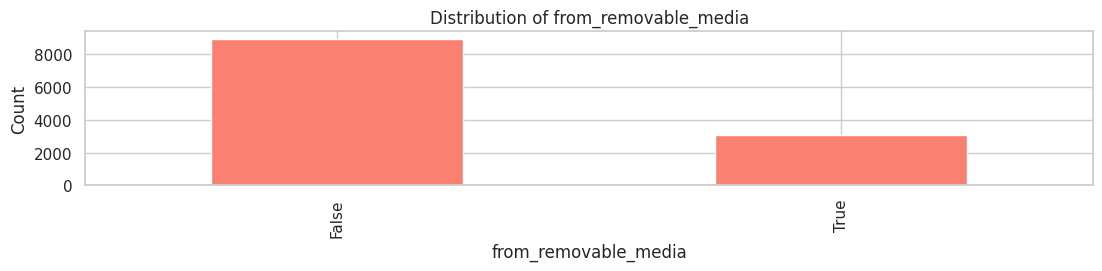

In [59]:
# ======================
# EDA: Bar charts
# ======================

categorical_cols = [
    "activity",
    "to_removable_media",
    "from_removable_media"
]

for col in categorical_cols:
    plt.figure(figsize=(13,2))
    df[col].value_counts().plot(kind="bar", color="salmon")
    plt.title(f"Distribution of {col}")
    plt.ylabel("Count")
    plt.show()


In [60]:
# ======================================================
# 3: Define X, y and feature groups
#    (drop all leakage / identity columns)
# ======================================================

# Convert target to int
df["is_insider"] = df["is_insider"].astype(int)

#Drop:
#  - id          -> row identifier
#  - event_src   -> which monitoring system produced the log (leakage)
#  - date        -> temporal leakage (insiders active in certain windows)
#  - user, pc    -> direct identity and machine identifiers
df_model = df.drop(columns=[
    "id",
    "event_src",          # leakage: monitoring source
    "date",               # leakage: time window
    "user",               # identity, too close to label
    "pc"                  # machine ID, too close to label
])

# Features (X) and label (y)
X = df_model.drop(columns=["is_insider"])
y = df_model["is_insider"]

# Numeric features (scaled)
numeric_features = [
    "size",
    "Openness score ",
    "Conscientiousness score",
    "Extraversion score",
    "Agreeableness score",
    "Neuroticism score"
]

# Categorical features (one-hot encoded)
categorical_features = [
    "activity",
    "to_removable_media",
    "from_removable_media"
]

print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

# Train/test split (80/20) with stratification to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Numeric: ['size', 'Openness score ', 'Conscientiousness score', 'Extraversion score', 'Agreeableness score', 'Neuroticism score']
Categorical: ['activity', 'to_removable_media', 'from_removable_media']
Train shape: (9600, 9)  Test shape: (2400, 9)


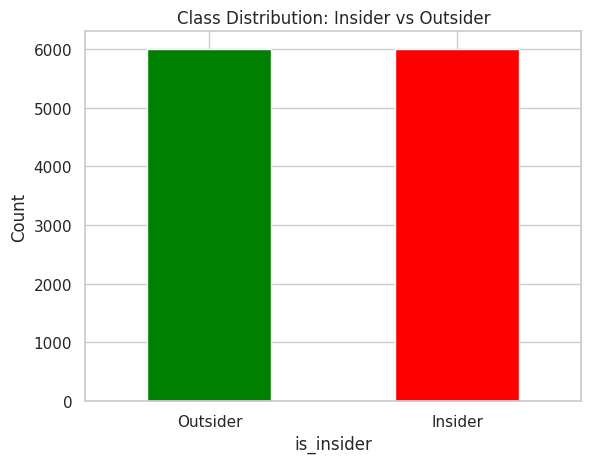

In [61]:
# ======================
# Dataset balance check
# ======================

df["is_insider"].value_counts().plot(kind="bar", color=["green", "red"])
plt.title("Class Distribution: Insider vs Outsider")
plt.xticks([0,1], ["Outsider", "Insider"], rotation=0)
plt.ylabel("Count")
plt.show()


In [62]:
# ======================================================
# 4: Build preprocessing pipeline
#    - Standardise numeric features
#    - One-hot encode categorical features
# ======================================================

numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print(preprocessor)


ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['size', 'Openness score ',
                                  'Conscientiousness score',
                                  'Extraversion score', 'Agreeableness score',
                                  'Neuroticism score']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['activity', 'to_removable_media',
                                  'from_removable_media'])])


In [63]:
# ======================================================
# 5: Shared evaluation helper
#    - computes metrics
#    - prints classification report
#    - plots confusion matrix with model-specific colour
#    - stores metrics in results dict
# ======================================================

results = {}   # dictionary to store metrics

# Define a colour map per model for visual variety
cmaps = {
    "NB":           "Greys",
    "FLM (LDA)":    "Purples",
    "DT":           "Oranges",
    "GLM (Logit)":  "Blues",
    "RF":           "Greens",
    "SVM":          "PuRd",
    "GBT":          "YlGnBu",
    "DL":           "Reds"
}

def evaluate_and_store(name, y_true, y_pred, y_proba):
    """
    Evaluate a model on the test set and store performance metrics.

    Parameters
    ----------
    name : str
        Name of the model. Also used as a key in the global `results` dict.
    y_true : array-like
        True binary labels (0 = Normal, 1 = Insider).
    y_pred : array-like
        Predicted class labels from the model.
    y_proba : array-like
        Predicted probability scores for the positive class (Insider).

    This function:
    -------------
    - Computes Accuracy, Classification Error, ROC-AUC, Precision, Recall, and F1-score.
    - Prints a full classification report.
    - Plots a confusion matrix using a model-specific colour map.
    - Saves the metrics into the global `results` dictionary for final comparison.
    """

    # Compute metrics
    acc  = accuracy_score(y_true, y_pred)
    ce   = 1 - acc
    auc  = roc_auc_score(y_true, y_proba)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)

    # Print metrics summary
    print(f"\n{name} – Test Metrics")
    print(f"Accuracy           : {acc:.4f}")
    print(f"Classification Err.: {ce:.4f}")
    print(f"ROC-AUC            : {auc:.4f}")
    print(f"Precision          : {prec:.4f}")
    print(f"Recall             : {rec:.4f}")
    print(f"F1-score           : {f1:.4f}\n")

    print("Classification report:\n")
    print(
        classification_report(
            y_true, y_pred,
            target_names=["Normal (0)", "Insider (1)"]
        )
    )

    # Confusion matrix with model-specific colour
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=cmaps.get(name, "Blues"),   # model-specific colour
        xticklabels=["Pred 0", "Pred 1"],
        yticklabels=["True 0", "True 1"]
    )
    plt.title(f"{name} – Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    # Save metrics in dictionary for comparison table
    results[name] = {
        "accuracy": acc,
        "classification_error": ce,
        "AUC": auc,
        "precision": prec,
        "recall": rec,
        "F1": f1
    }



NB – Test Metrics
Accuracy           : 0.9396
Classification Err.: 0.0604
ROC-AUC            : 0.9396
Precision          : 0.8922
Recall             : 1.0000
F1-score           : 0.9430

Classification report:

              precision    recall  f1-score   support

  Normal (0)       1.00      0.88      0.94      1200
 Insider (1)       0.89      1.00      0.94      1200

    accuracy                           0.94      2400
   macro avg       0.95      0.94      0.94      2400
weighted avg       0.95      0.94      0.94      2400



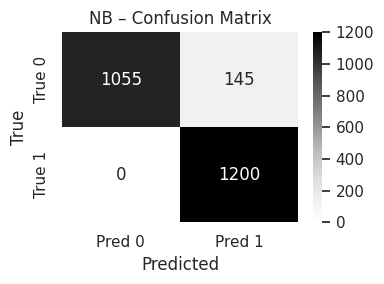

In [64]:
# ======================================================
# 6: Naive Bayes (NB)
#    Simple probabilistic baseline
# ======================================================

nb_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GaussianNB())
])

nb_clf.fit(X_train, y_train)

y_pred_nb  = nb_clf.predict(X_test)
y_proba_nb = nb_clf.predict_proba(X_test)[:, 1]

evaluate_and_store("NB", y_test, y_pred_nb, y_proba_nb)



FLM (LDA) – Test Metrics
Accuracy           : 0.9396
Classification Err.: 0.0604
ROC-AUC            : 0.9907
Precision          : 0.8922
Recall             : 1.0000
F1-score           : 0.9430

Classification report:

              precision    recall  f1-score   support

  Normal (0)       1.00      0.88      0.94      1200
 Insider (1)       0.89      1.00      0.94      1200

    accuracy                           0.94      2400
   macro avg       0.95      0.94      0.94      2400
weighted avg       0.95      0.94      0.94      2400



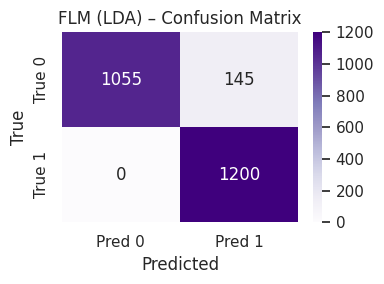

In [65]:
# ======================================================
# 7: Fisher Linear Model (FLM) – Linear Discriminant Analysis
#    - Linear boundary, good as "flat" baseline
# ======================================================

lda_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearDiscriminantAnalysis())
])

lda_clf.fit(X_train, y_train)

y_pred_lda  = lda_clf.predict(X_test)
y_proba_lda = lda_clf.predict_proba(X_test)[:, 1]

evaluate_and_store("FLM (LDA)", y_test, y_pred_lda, y_proba_lda)



DT – Test Metrics
Accuracy           : 0.9983
Classification Err.: 0.0017
ROC-AUC            : 0.9983
Precision          : 0.9967
Recall             : 1.0000
F1-score           : 0.9983

Classification report:

              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00      1200
 Insider (1)       1.00      1.00      1.00      1200

    accuracy                           1.00      2400
   macro avg       1.00      1.00      1.00      2400
weighted avg       1.00      1.00      1.00      2400



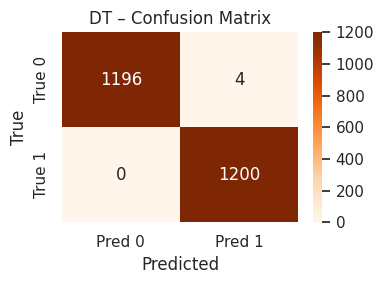

In [66]:
# ======================================================
# 8: Decision Tree (DT)
#    - Single tree, interpretable rules
# ======================================================

dt_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=None,
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ))
])

dt_clf.fit(X_train, y_train)

y_pred_dt  = dt_clf.predict(X_test)
y_proba_dt = dt_clf.predict_proba(X_test)[:, 1]

evaluate_and_store("DT", y_test, y_pred_dt, y_proba_dt)



GLM (Logit) – Test Metrics
Accuracy           : 0.9546
Classification Err.: 0.0454
ROC-AUC            : 0.9911
Precision          : 0.9389
Recall             : 0.9725
F1-score           : 0.9554

Classification report:

              precision    recall  f1-score   support

  Normal (0)       0.97      0.94      0.95      1200
 Insider (1)       0.94      0.97      0.96      1200

    accuracy                           0.95      2400
   macro avg       0.96      0.95      0.95      2400
weighted avg       0.96      0.95      0.95      2400



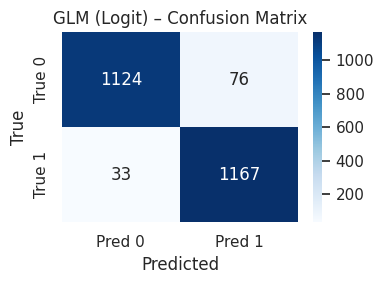

['insider_glm_logit.pkl']

In [67]:
# ======================================================
# 9: Generalised Linear Model (GLM – Logistic Regression)
#    - Logit link, baseline linear classifier
# ======================================================

glm_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

glm_clf.fit(X_train, y_train)

y_pred_glm  = glm_clf.predict(X_test)
y_proba_glm = glm_clf.predict_proba(X_test)[:, 1]

evaluate_and_store("GLM (Logit)", y_test, y_pred_glm, y_proba_glm)

# Save GLM model
joblib.dump(glm_clf, "insider_glm_logit.pkl")



RF – Test Metrics
Accuracy           : 0.9967
Classification Err.: 0.0033
ROC-AUC            : 1.0000
Precision          : 0.9934
Recall             : 1.0000
F1-score           : 0.9967

Classification report:

              precision    recall  f1-score   support

  Normal (0)       1.00      0.99      1.00      1200
 Insider (1)       0.99      1.00      1.00      1200

    accuracy                           1.00      2400
   macro avg       1.00      1.00      1.00      2400
weighted avg       1.00      1.00      1.00      2400



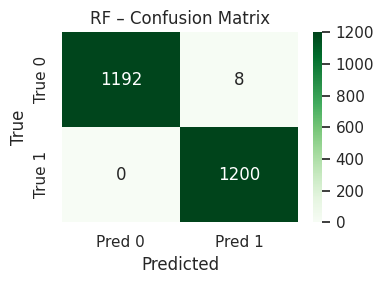

['insider_random_forest.pkl']

In [68]:
# ======================================================
# 10: Random Forest (RF)
#     - Ensemble of decision trees
# ======================================================

rf_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_clf.fit(X_train, y_train)

y_pred_rf  = rf_clf.predict(X_test)
y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

evaluate_and_store("RF", y_test, y_pred_rf, y_proba_rf)

joblib.dump(rf_clf, "insider_random_forest.pkl")



SVM – Test Metrics
Accuracy           : 0.9846
Classification Err.: 0.0154
ROC-AUC            : 0.9964
Precision          : 0.9724
Recall             : 0.9975
F1-score           : 0.9848

Classification report:

              precision    recall  f1-score   support

  Normal (0)       1.00      0.97      0.98      1200
 Insider (1)       0.97      1.00      0.98      1200

    accuracy                           0.98      2400
   macro avg       0.98      0.98      0.98      2400
weighted avg       0.98      0.98      0.98      2400



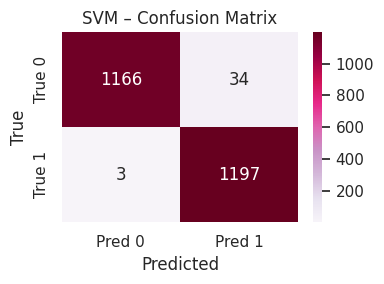

In [69]:
# ======================================================
# 11: SVM with RBF kernel
#     - Non-linear margin-based classifier
# ======================================================

svm_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", SVC(
        kernel="rbf",
        probability=True,           # needed for ROC-AUC
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

svm_clf.fit(X_train, y_train)

y_pred_svm  = svm_clf.predict(X_test)
y_proba_svm = svm_clf.predict_proba(X_test)[:, 1]

evaluate_and_store("SVM", y_test, y_pred_svm, y_proba_svm)



GBT – Test Metrics
Accuracy           : 0.9967
Classification Err.: 0.0033
ROC-AUC            : 1.0000
Precision          : 0.9934
Recall             : 1.0000
F1-score           : 0.9967

Classification report:

              precision    recall  f1-score   support

  Normal (0)       1.00      0.99      1.00      1200
 Insider (1)       0.99      1.00      1.00      1200

    accuracy                           1.00      2400
   macro avg       1.00      1.00      1.00      2400
weighted avg       1.00      1.00      1.00      2400



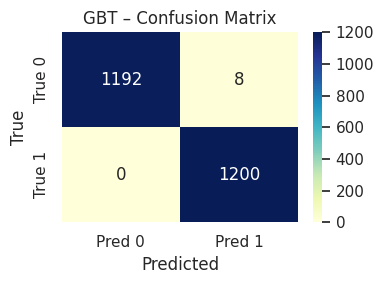

In [70]:
# ======================================================
# 12: Gradient Boosted Trees (GBT – XGBoost)
# ======================================================

xgb_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

xgb_clf.fit(X_train, y_train)

y_pred_xgb  = xgb_clf.predict(X_test)
y_proba_xgb = xgb_clf.predict_proba(X_test)[:, 1]

evaluate_and_store("GBT", y_test, y_pred_xgb, y_proba_xgb)


In [71]:
# ======================================================
# K-FOLD CROSS-VALIDATION (on training set only)
# ======================================================

#5-fold stratified CV on the training set only for the main models:
#GLM (Logit), Random Forest, SVM, XGBoost (GBT)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Models to include in CV
models_for_cv = {
    "GLM (Logit)": glm_clf,
    "RF": rf_clf,
    "SVM": svm_clf,
    "GBT": xgb_clf
}

# Multiple metrics for each fold
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = {}

for name, model in models_for_cv.items():
    print(f"\nRunning 5-fold CV for: {name}")
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    # Store mean and std for each metric
    summary = {
        f"{metric}_mean":  scores[f"test_{metric}"].mean()
        for metric in scoring.keys()
    }
    summary.update({
        f"{metric}_std":   scores[f"test_{metric}"].std()
        for metric in scoring.keys()
    })

    cv_results[name] = summary

# Put into a nice table
cv_df = pd.DataFrame(cv_results).T
cv_df = cv_df.round(4)

print("\nCross-Validation Results (5-fold, training set):")
display(cv_df)



Running 5-fold CV for: GLM (Logit)

Running 5-fold CV for: RF

Running 5-fold CV for: SVM

Running 5-fold CV for: GBT

Cross-Validation Results (5-fold, training set):


,accuracy_mean,precision_mean,recall_mean,f1_mean,roc_auc_mean,accuracy_std,precision_std,recall_std,f1_std,roc_auc_std
GLM (Logit),0.9507,0.9374,0.9660,0.9515,0.9902,0.0023,0.0057,0.0054,0.0023,0.0005
RF,0.9973,0.9948,0.9998,0.9973,1.0000,0.0008,0.0015,0.0004,0.0008,0.0000
SVM,0.9794,0.9704,0.9890,0.9796,0.9955,0.0048,0.0066,0.0041,0.0047,0.0017
GBT,0.9978,0.9959,0.9998,0.9978,0.9998,0.0012,0.0024,0.0004,0.0012,0.0002


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best RF parameters: {'model__n_estimators': 400, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': None}
Best RF CV ROC-AUC: 0.9999958767361111

RF (tuned) – Test Metrics
Accuracy           : 0.9967
Classification Err.: 0.0033
ROC-AUC            : 1.0000
Precision          : 0.9934
Recall             : 1.0000
F1-score           : 0.9967

Classification report:

              precision    recall  f1-score   support

  Normal (0)       1.00      0.99      1.00      1200
 Insider (1)       0.99      1.00      1.00      1200

    accuracy                           1.00      2400
   macro avg       1.00      1.00      1.00      2400
weighted avg       1.00      1.00      1.00      2400



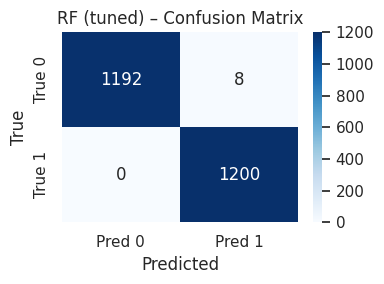

In [72]:
# ======================================================
# HYPERPARAMETER TUNING – Random Forest (RF)
# ======================================================

rf_base = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ))
])

rf_param_dist = {
    "model__n_estimators": [100, 200, 300, 400],
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None]
}

rf_search = RandomizedSearchCV(
    rf_base,
    param_distributions=rf_param_dist,
    n_iter=20,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

rf_search.fit(X_train, y_train)

print("Best RF parameters:", rf_search.best_params_)
print("Best RF CV ROC-AUC:", rf_search.best_score_)

rf_best = rf_search.best_estimator_

y_pred_rf_tuned  = rf_best.predict(X_test)
y_proba_rf_tuned = rf_best.predict_proba(X_test)[:, 1]

evaluate_and_store("RF (tuned)", y_test, y_pred_rf_tuned, y_proba_rf_tuned)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best XGB parameters: {'model__subsample': 1.0, 'model__n_estimators': 200, 'model__min_child_weight': 1, 'model__max_depth': 5, 'model__learning_rate': 0.1, 'model__gamma': 0.3, 'model__colsample_bytree': 1.0}
Best XGB CV ROC-AUC: 0.9998283420138889

GBT (tuned) – Test Metrics
Accuracy           : 0.9967
Classification Err.: 0.0033
ROC-AUC            : 0.9997
Precision          : 0.9934
Recall             : 1.0000
F1-score           : 0.9967

Classification report:

              precision    recall  f1-score   support

  Normal (0)       1.00      0.99      1.00      1200
 Insider (1)       0.99      1.00      1.00      1200

    accuracy                           1.00      2400
   macro avg       1.00      1.00      1.00      2400
weighted avg       1.00      1.00      1.00      2400



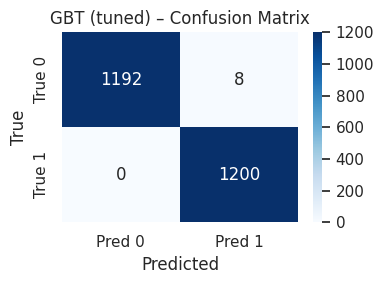

In [73]:
# ------------------------------------------------------
# Hyperparameter search space for XGBoost
# Each entry is a list of candidate values; RandomizedSearchCV
# will try random combinations and keep the best one by ROC-AUC.
# ------------------------------------------------------

xgb_base = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])


xgb_param_dist = {
    # Number of boosting trees (more trees = more capacity, but slower)
    "model__n_estimators": [200, 300, 400],

    # Maximum depth of each tree (controls model complexity / overfitting)
    "model__max_depth": [3, 5, 7], #deep of tree

    # Learning rate / step size for each boosting iteration
    "model__learning_rate": [0.01, 0.05, 0.1],

    # Subsample ratio for training rows (stochasticity + regularisation)
    "model__subsample": [0.7, 0.8, 1.0],

    # Subsample ratio for features at each split (column sampling)
    "model__colsample_bytree": [0.7, 0.8, 1.0],

    # Minimum sum of instance weights (or sample count) in a child node;
    # larger values make the model more conservative.
    "model__min_child_weight": [1, 3, 5],

    # Minimum loss reduction required to make a further split;
    # larger gamma = fewer splits = stronger regularisation.
    "model__gamma": [0, 0.1, 0.3]
}

xgb_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=xgb_param_dist,
    n_iter=20,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

xgb_search.fit(X_train, y_train)

print("Best XGB parameters:", xgb_search.best_params_)
print("Best XGB CV ROC-AUC:", xgb_search.best_score_)

xgb_best = xgb_search.best_estimator_

y_pred_xgb_tuned  = xgb_best.predict(X_test)
y_proba_xgb_tuned = xgb_best.predict_proba(X_test)[:, 1]

evaluate_and_store("GBT (tuned)", y_test, y_pred_xgb_tuned, y_proba_xgb_tuned)


Top 15 features by importance (GBT tuned):


,feature,importance
10,activity_Logon,0.602831
11,to_removable_media_False,0.209177
13,from_removable_media_False,0.107588
5,Neuroticism score,0.018894
1,Openness score,0.016954
0,size,0.014995
4,Agreeableness score,0.011217
3,Extraversion score,0.009241
2,Conscientiousness score,0.008550
9,activity_Logoff,0.000551


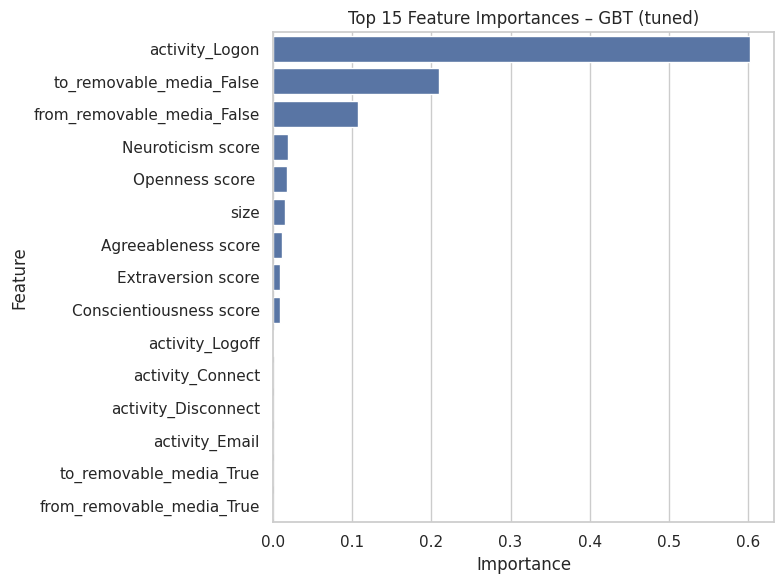

In [74]:
# ======================================================
# Feature importance for tuned XGBoost (GBT)
# ======================================================

# Rebuild feature names from preprocessor
ohe = preprocessor.named_transformers_["cat"]
cat_feature_names = list(ohe.get_feature_names_out(categorical_features))
all_feature_names = numeric_features + cat_feature_names

xgb_model = xgb_best.named_steps["model"]
importances = xgb_model.feature_importances_

fi_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("Top 15 features by importance (GBT tuned):")
display(fi_df.head(15))

plt.figure(figsize=(8,6))
sns.barplot(
    data=fi_df.head(15),
    x="importance", y="feature",
    orient="h"
)
plt.title("Top 15 Feature Importances – GBT (tuned)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


Epoch 1/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7868 - loss: 0.4596 - val_accuracy: 0.9531 - val_loss: 0.1026
Epoch 2/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9643 - loss: 0.0999 - val_accuracy: 0.9740 - val_loss: 0.0797
Epoch 3/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9708 - loss: 0.0828 - val_accuracy: 0.9750 - val_loss: 0.0716
Epoch 4/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9726 - loss: 0.0769 - val_accuracy: 0.9740 - val_loss: 0.0703
Epoch 5/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9757 - loss: 0.0663 - val_accuracy: 0.9786 - val_loss: 0.0633
Epoch 6/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9779 - loss: 0.0633 - val_accuracy: 0.9797 - val_loss: 0.0584
Epoch 7/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9757 - loss: 0.0732 - val_accuracy: 0.9776 - val_loss: 0.0575
Epoch 8/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9762 - loss: 0.0661 - val_accuracy: 0.

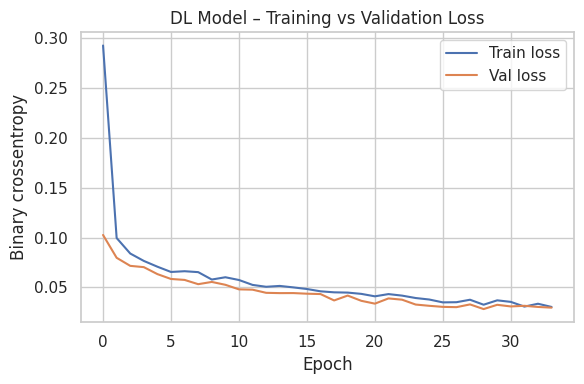

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

DL – Test Metrics
Accuracy           : 0.9892
Classification Err.: 0.0108
ROC-AUC            : 0.9989
Precision          : 0.9827
Recall             : 0.9958
F1-score           : 0.9892

Classification report:

              precision    recall  f1-score   support

  Normal (0)       1.00      0.98      0.99      1200
 Insider (1)       0.98      1.00      0.99      1200

    accuracy                           0.99      2400
   macro avg       0.99      0.99      0.99      2400
weighted avg       0.99      0.99      0.99      2400



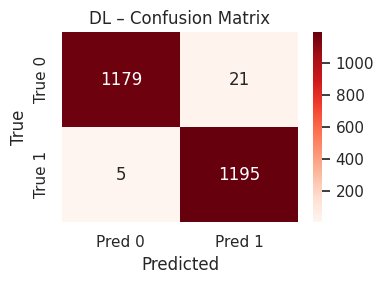

['insider_preprocessor_for_dl.pkl']

In [75]:
# ======================================================
# 13: Deep Learning model (DL – Feed-forward Neural Network)
#     - Non-linear representation learner on tabular data
# ======================================================

# Fit preprocessor on training data only (to avoid peeking at test)
preprocessor_dl = preprocessor.fit(X_train)

X_train_dl = preprocessor_dl.transform(X_train)
X_test_dl  = preprocessor_dl.transform(X_test)

# Convert sparse matrix (from OneHotEncoder) to dense for Keras
if hasattr(X_train_dl, "toarray"):
    X_train_dl = X_train_dl.toarray()
    X_test_dl  = X_test_dl.toarray()

input_dim = X_train_dl.shape[1]

# Define simple fully-connected network
model_dl = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")   # output = probability of insider
])

model_dl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Early stopping to avoid overfitting
es = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model_dl.fit(
    X_train_dl, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[es],
    verbose=1
)

# Training history plot for DL
hist = history.history

plt.figure(figsize=(6,4))
plt.plot(hist["loss"], label="Train loss")
plt.plot(hist["val_loss"], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Binary crossentropy")
plt.title("DL Model – Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()


# Evaluate on test set
y_proba_dl = model_dl.predict(X_test_dl).ravel()
y_pred_dl  = (y_proba_dl >= 0.5).astype(int)

evaluate_and_store("DL", y_test, y_pred_dl, y_proba_dl)

# Save DL model (new Keras recommended format)
model_dl.save("insider_deep_nn.keras")

# Save preprocessor
joblib.dump(preprocessor_dl, "insider_preprocessor_for_dl.pkl")



In [76]:
# ===========================================
# Hyperparameter Tuning Summary (RF + GBT)
# ===========================================

print("Best RF parameters:\n", rf_search.best_params_)
print("\nBest XGB parameters:\n", xgb_search.best_params_)


Best RF parameters:
 {'model__n_estimators': 400, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': None}

Best XGB parameters:
 {'model__subsample': 1.0, 'model__n_estimators': 200, 'model__min_child_weight': 1, 'model__max_depth': 5, 'model__learning_rate': 0.1, 'model__gamma': 0.3, 'model__colsample_bytree': 1.0}


In [77]:
# ===========================================
# Deep Learning Architecture Summary
# ===========================================
model_dl.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,109 (121.52 KB)

 Trainable params: 10,369 (40.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 20,740 (81.02 KB)

In [78]:
# ===========================================
# Random Forest tree stats
# ===========================================
rf_model = rf_best.named_steps["model"]
print("Random Forest n_estimators:", rf_model.n_estimators)
print("Random Forest max_depth:", rf_model.max_depth)

# XGBoost tree stats
xgb_model = xgb_best.named_steps["model"]
print("XGB n_estimators:", xgb_model.n_estimators)
print("XGB max_depth:", xgb_model.max_depth)


Random Forest n_estimators: 400
Random Forest max_depth: None
XGB n_estimators: 200
XGB max_depth: 5


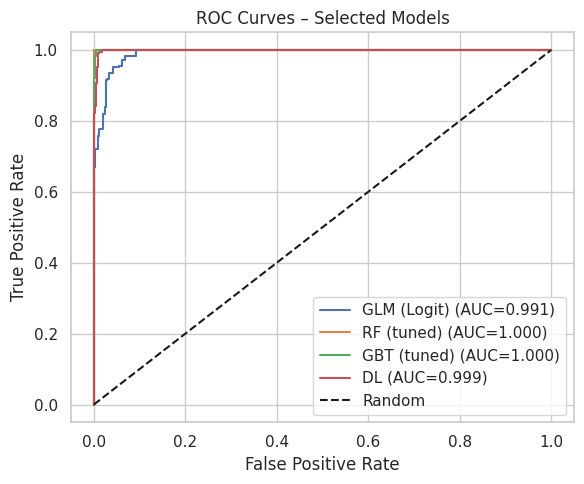

In [102]:
# ======================================================
# ROC curves for selected models
# ======================================================
from sklearn.metrics import roc_curve

# Collect true labels and probabilities for main models
roc_models = {
    "GLM (Logit)": y_proba_glm,
    "RF (tuned)":  y_proba_rf_tuned,
    "GBT (tuned)": y_proba_xgb_tuned,
    "DL":          y_proba_dl
}

plt.figure(figsize=(6,5))

for name, y_proba in roc_models.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = results[name]["AUC"]
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1], [0,1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves – Selected Models")
plt.legend()
plt.tight_layout()
plt.show()


Insider Threat – Model Benchmark


,accuracy,classification_error,AUC,precision,recall,F1
NB,0.9396,0.0604,0.9396,0.8922,1.0000,0.9430
FLM (LDA),0.9396,0.0604,0.9907,0.8922,1.0000,0.9430
DT,0.9983,0.0017,0.9983,0.9967,1.0000,0.9983
GLM (Logit),0.9546,0.0454,0.9911,0.9389,0.9725,0.9554
RF,0.9967,0.0033,1.0000,0.9934,1.0000,0.9967
SVM,0.9846,0.0154,0.9964,0.9724,0.9975,0.9848
GBT,0.9967,0.0033,1.0000,0.9934,1.0000,0.9967
RF (tuned),0.9967,0.0033,1.0000,0.9934,1.0000,0.9967
GBT (tuned),0.9967,0.0033,0.9997,0.9934,1.0000,0.9967
DL,0.9892,0.0108,0.9989,0.9827,0.9958,0.9892


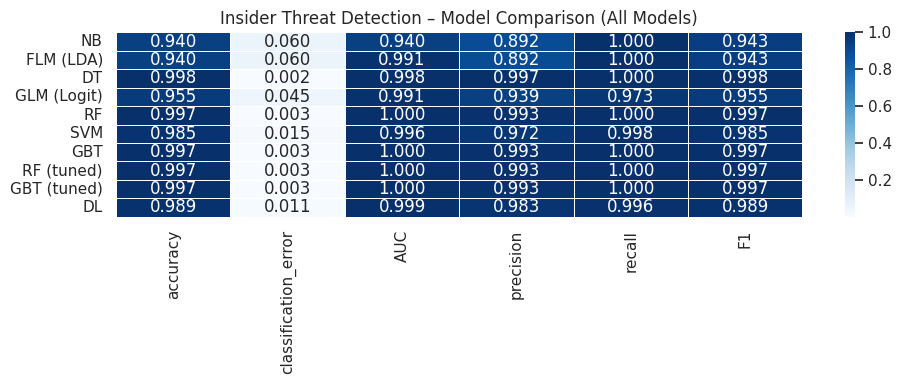

In [80]:
# ======================================================
# 14: Final model comparison table + heatmap
# ======================================================

df_results = pd.DataFrame(results).T
df_results = df_results[[
    "accuracy", "classification_error",
    "AUC", "precision", "recall", "F1"
]].round(4)

print("Insider Threat – Model Benchmark")
display(df_results)

plt.figure(figsize=(10, 4))
sns.heatmap(
    df_results.astype(float),
    annot=True, fmt=".3f",
    cmap="Blues",
    cbar=True,
    linewidths=.5
)
plt.title("Insider Threat Detection – Model Comparison (All Models)")
plt.tight_layout()
plt.show()


Insider Threat – Model Benchmark (sorted by F1)


,accuracy,classification_error,AUC,precision,recall,F1
DT,0.9983,0.0017,0.9983,0.9967,1.0000,0.9983
RF,0.9967,0.0033,1.0000,0.9934,1.0000,0.9967
GBT (tuned),0.9967,0.0033,0.9997,0.9934,1.0000,0.9967
GBT,0.9967,0.0033,1.0000,0.9934,1.0000,0.9967
RF (tuned),0.9967,0.0033,1.0000,0.9934,1.0000,0.9967
DL,0.9892,0.0108,0.9989,0.9827,0.9958,0.9892
SVM,0.9846,0.0154,0.9964,0.9724,0.9975,0.9848
GLM (Logit),0.9546,0.0454,0.9911,0.9389,0.9725,0.9554
FLM (LDA),0.9396,0.0604,0.9907,0.8922,1.0000,0.9430
NB,0.9396,0.0604,0.9396,0.8922,1.0000,0.9430


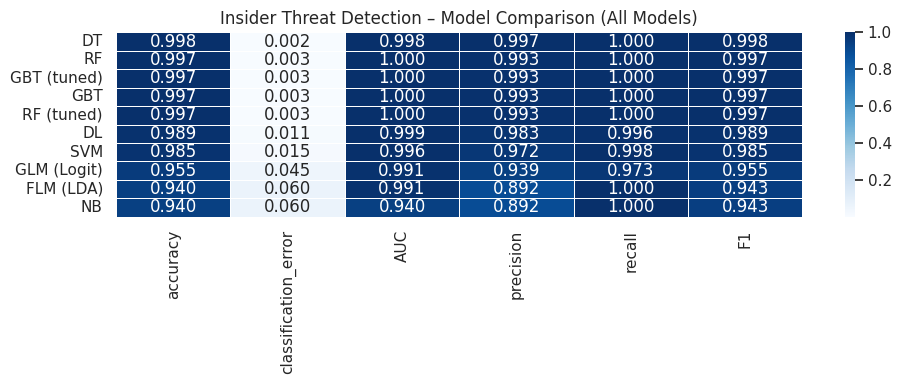

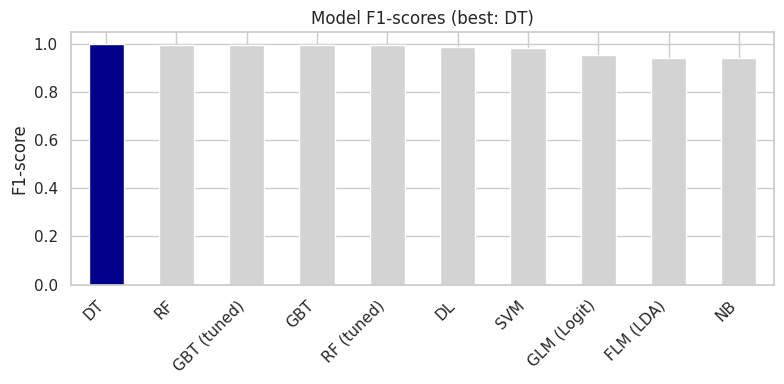

In [81]:
# ======================================================
# 14: Final model comparison table + visualisations
# ======================================================

df_results = pd.DataFrame(results).T
df_results = df_results[[
    "accuracy", "classification_error",
    "AUC", "precision", "recall", "F1"
]].round(4)

# Sort by F1 (best at top)
df_results_sorted = df_results.sort_values("F1", ascending=False)

print("Insider Threat – Model Benchmark (sorted by F1)")
display(df_results_sorted)

# Heatmap of metrics
plt.figure(figsize=(10, 4))
sns.heatmap(
    df_results_sorted.astype(float),
    annot=True, fmt=".3f",
    cmap="Blues",
    cbar=True,
    linewidths=.5
)
plt.title("Insider Threat Detection – Model Comparison (All Models)")
plt.tight_layout()
plt.show()

# Bar chart for F1 with best model highlighted
best_model = df_results_sorted["F1"].idxmax()
colors = ["lightgrey"] * len(df_results_sorted)
best_idx = list(df_results_sorted.index).index(best_model)
colors[best_idx] = "darkblue"

plt.figure(figsize=(8,4))
df_results_sorted["F1"].plot(kind="bar", color=colors)
plt.title(f"Model F1-scores (best: {best_model})")
plt.ylabel("F1-score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [103]:
# ======================================================
# Threshold analysis for best model (example: GBT tuned)
# ======================================================

def print_metrics_at_threshold(y_true, y_proba, thresh):
    y_pred_thresh = (y_proba >= thresh).astype(int)
    print(f"\n--- Threshold = {thresh:.2f} ---")
    print("Precision:", precision_score(y_true, y_pred_thresh))
    print("Recall   :", recall_score(y_true, y_pred_thresh))
    print("F1-score :", f1_score(y_true, y_pred_thresh))

thresholds_to_test = [0.30, 0.50, 0.70]
for t in thresholds_to_test:
    print_metrics_at_threshold(y_test, y_proba_xgb_tuned, t)



--- Threshold = 0.30 ---
Precision: 0.9900990099009901
Recall   : 1.0
F1-score : 0.9950248756218906

--- Threshold = 0.50 ---
Precision: 0.9933774834437086
Recall   : 1.0
F1-score : 0.9966777408637874

--- Threshold = 0.70 ---
Precision: 0.9950248756218906
Recall   : 1.0
F1-score : 0.9975062344139651


In [82]:
# ===========================================
# Summary Printout
# ===========================================
best_f1_model = df_results_sorted["F1"].idxmax()
best_auc_model = df_results_sorted["AUC"].idxmax()

print("Best model by F1:", best_f1_model,
      "with F1 =", df_results_sorted.loc[best_f1_model, "F1"])
print("Best model by AUC:", best_auc_model,
      "with AUC =", df_results_sorted.loc[best_auc_model, "AUC"])


Best model by F1: DT with F1 = 0.9983
Best model by AUC: RF with AUC = 1.0


Number of misclassifications: 8

Misclassifications by activity:
activity
Logon    8
Name: count, dtype: int64


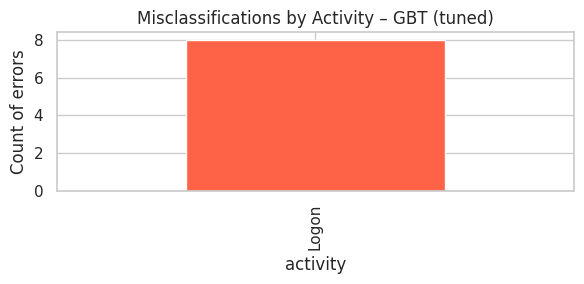

In [105]:
# ======================================================
# Error analysis for best model (GBT tuned) by activity
# ======================================================

# Get predictions at default threshold 0.5
y_pred_best = (y_proba_xgb_tuned >= 0.5).astype(int)

# Attach to a copy of test set with the original activity column
test_with_preds = X_test.copy()
test_with_preds["true_label"] = y_test.values
test_with_preds["pred_label"] = y_pred_best

# Misclassified rows only
errors = test_with_preds[test_with_preds["true_label"] != test_with_preds["pred_label"]]

print("Number of misclassifications:", len(errors))

# Count errors by activity type
err_by_activity = errors["activity"].value_counts()
print("\nMisclassifications by activity:")
print(err_by_activity)

plt.figure(figsize=(6, 3))
err_by_activity.plot(kind="bar", color="tomato")
plt.title("Misclassifications by Activity – GBT (tuned)")
plt.ylabel("Count of errors")
plt.tight_layout()
plt.show()


In [83]:
# ===========================================
# 1) Go to your repo folder in Colab
# ===========================================
%cd /content/Detecting-Insider-Threats-through-Behavioral-AI_Dissertation

# 2) Make sure we are using the clean remote URL (no token in it)
!git remote set-url origin https://github.com/egyinmoe/Detecting-Insider-Threats-through-Behavioral-AI_Dissertation.git

# 3) Reset local repo to match GitHub main (this removes the BAD commit with the token)
!git fetch origin
!git reset --hard origin/main


/content/Detecting-Insider-Threats-through-Behavioral-AI_Dissertation
remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 16 (delta 9), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (16/16), 654.25 KiB | 1.91 MiB/s, done.
From https://github.com/egyinmoe/Detecting-Insider-Threats-through-Behavioral-AI_Dissertation
   f59d93d..13cdd3f  main       -> origin/main
HEAD is now at 13cdd3f Add detailed documentation and improved structure to evaluation helper function


In [84]:
# 4) Copy the UPDATED notebook (the one you just edited in Colab Drive)
#    Make sure this path is correct – this is where your notebook lives
!cp "/content/drive/MyDrive/Colab Notebooks/Ver2_Insiderthreat_withgithub.ipynb" \
    /content/Detecting-Insider-Threats-through-Behavioral-AI_Dissertation/

# 5) Check files in the repo folder
!ls -al


total 3284
drwxr-xr-x 3 root root    4096 Nov 22 15:36 .
drwxr-xr-x 1 root root    4096 Nov 22 13:42 ..
drwxr-xr-x 8 root root    4096 Nov 22 15:36 .git
-rw-r--r-- 1 root root  154184 Nov 22 15:35 insider_deep_nn.keras
-rw-r--r-- 1 root root    4129 Nov 22 15:32 insider_glm_logit.pkl
-rw-r--r-- 1 root root    3284 Nov 22 15:35 insider_preprocessor_for_dl.pkl
-rw-r--r-- 1 root root 2587474 Nov 22 15:32 insider_random_forest.pkl
-rw-r--r-- 1 root root   24862 Nov 22 13:42 mergefile_dataset1.ipynb
-rw-r--r-- 1 root root    3483 Nov 22 13:42 README.md
-rw-r--r-- 1 root root  559273 Nov 22 15:36 Ver2_Insiderthreat_withgithub.ipynb


In [85]:
# 6) Configure the Git identity (only needed once per Colab session)

!git config --global user.email "eingyinmoe19@gmail.com"
!git config --global user.name "Ein Gyin Moe"

# (OPTIONAL) Check it:
!git config --global user.email
!git config --global user.name


eingyinmoe19@gmail.com
Ein Gyin Moe


In [86]:
# 7) Stage the updated notebook
!git add Ver2_Insiderthreat_withgithub.ipynb

# 8) See what will be committed
!git status


On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	modified:   Ver2_Insiderthreat_withgithub.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	insider_deep_nn.keras
	insider_glm_logit.pkl
	insider_preprocessor_for_dl.pkl
	insider_random_forest.pkl



In [87]:
# 9) Commit the changes
!git commit -m "Update insider threat modelling (drop leakage, add SVM/XGBoost/DL)"


[main b0f45e2] Update insider threat modelling (drop leakage, add SVM/XGBoost/DL)
 1 file changed, 1 insertion(+), 4773 deletions(-)
 rewrite Ver2_Insiderthreat_withgithub.ipynb (93%)


In [88]:
!git clone https://github.com/egyinmoe/Detecting-Insider-Threats-through-Behavioral-AI_Dissertation.git


Cloning into 'Detecting-Insider-Threats-through-Behavioral-AI_Dissertation'...
remote: Enumerating objects: 53, done.
remote: Counting objects: 100% (53/53), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 53 (delta 21), reused 3 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (53/53), 1.33 MiB | 7.51 MiB/s, done.
Resolving deltas: 100% (21/21), done.


In [89]:
%cd Detecting-Insider-Threats-through-Behavioral-AI_Dissertation


/content/Detecting-Insider-Threats-through-Behavioral-AI_Dissertation/Detecting-Insider-Threats-through-Behavioral-AI_Dissertation


In [90]:
!find / -name "*.ipynb" 2>/dev/null


/usr/local/lib/python3.12/dist-packages/nbclassic/bundler/tests/resources/empty.ipynb
/usr/local/lib/python3.12/dist-packages/notebook/bundler/tests/resources/empty.ipynb
/usr/local/lib/python3.12/dist-packages/panel/tests/ui/io/app.ipynb
/usr/local/lib/python3.12/dist-packages/wasabi/tests/test-data/wasabi-test-notebook.ipynb
/usr/local/lib/python3.12/dist-packages/flax/core/flax_functional_engine.ipynb
/usr/local/lib/python3.12/dist-packages/cuml/experimental/hyperparams/HPO_demo.ipynb
/usr/local/lib/python3.12/dist-packages/holoviews/examples/getting_started/5-Live_Data.ipynb
/usr/local/lib/python3.12/dist-packages/holoviews/examples/getting_started/2-Customization.ipynb
/usr/local/lib/python3.12/dist-packages/holoviews/examples/getting_started/3-Tabular_Datasets.ipynb
/usr/local/lib/python3.12/dist-packages/holoviews/examples/getting_started/1-Introduction.ipynb
/usr/local/lib/python3.12/dist-packages/holoviews/examples/getting_started/4-Gridded_Datasets.ipynb
/usr/local/lib/python

In [91]:
!cp "/content/drive/MyDrive/Colab Notebooks/Ver2_Insiderthreat_withgithub.ipynb" \
    /content/Detecting-Insider-Threats-through-Behavioral-AI_Dissertation/


In [92]:
!ls -al /content/Detecting-Insider-Threats-through-Behavioral-AI_Dissertation/


total 3288
drwxr-xr-x 4 root root    4096 Nov 22 15:36 .
drwxr-xr-x 1 root root    4096 Nov 22 13:42 ..
drwxr-xr-x 3 root root    4096 Nov 22 15:36 Detecting-Insider-Threats-through-Behavioral-AI_Dissertation
drwxr-xr-x 8 root root    4096 Nov 22 15:36 .git
-rw-r--r-- 1 root root  154184 Nov 22 15:35 insider_deep_nn.keras
-rw-r--r-- 1 root root    4129 Nov 22 15:32 insider_glm_logit.pkl
-rw-r--r-- 1 root root    3284 Nov 22 15:35 insider_preprocessor_for_dl.pkl
-rw-r--r-- 1 root root 2587474 Nov 22 15:32 insider_random_forest.pkl
-rw-r--r-- 1 root root   24862 Nov 22 13:42 mergefile_dataset1.ipynb
-rw-r--r-- 1 root root    3483 Nov 22 13:42 README.md
-rw-r--r-- 1 root root  559273 Nov 22 15:36 Ver2_Insiderthreat_withgithub.ipynb


In [93]:
!git status


On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [94]:
!git add Ver2_Insiderthreat_withgithub.ipynb


In [95]:
%cd /content/Detecting-Insider-Threats-through-Behavioral-AI_Dissertation


/content/Detecting-Insider-Threats-through-Behavioral-AI_Dissertation


In [96]:
!git config --global user.email "eingyinmoe19@gmail.com"
!git config --global user.name "Ein Gyin Moe"


In [97]:
!git commit -m "Add additional models and remove user/pc leakage"


On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	Detecting-Insider-Threats-through-Behavioral-AI_Dissertation/
	insider_deep_nn.keras
	insider_glm_logit.pkl
	insider_preprocessor_for_dl.pkl
	insider_random_forest.pkl

nothing added to commit but untracked files present (use "git add" to track)
